In [3]:
import cv2
import numpy as np
from PIL import Image
from rembg import remove
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm
import shutil
import random

### Preprocessing-1 (Grayscale)

Gambar dimuat, diubah ukurannya menjadi 480×640 dengan interpolasi kubik, dikonversi ke skala abu-abu (grayscale), lalu background dihilangkan menggunakan library `rembg`.

In [2]:
# def preprocessing_1(image_path):
#     """
#     Preprocessing-1: Load, Resize 480x640, Grayscale, Background Removal
#     Berdasarkan Tabel 5.3
#     """
#     img = cv2.imread(image_path)
#     img_resized = cv2.resize(img, dsize=(480, 640), interpolation=cv2.INTER_CUBIC)
#     img_resized = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
#     input_image = Image.fromarray(img_resized)
#     output_image = remove(input_image)
#     return output_image

def preprocessing_1(image_path):
    """
    Preprocessing-1: Load, Resize 480x640, Background Removal on RGB!
    """
    img = cv2.imread(image_path)
    
    # Convert BGR (OpenCV default) to RGB for rembg
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, dsize=(480, 640), interpolation=cv2.INTER_CUBIC)
    
    input_image = Image.fromarray(img_resized)
    output_image = remove(input_image) # rembg works much better on RGB
    return output_image

### Preprocessing-2 (Gaussian Blur dan Otsu Thresholding)

Gambar dari preprocessing-1 diubah ke array numpy, dilakukan perluasan gambar dengan penambahan tinggi 160 pixel (80 di atas dan 80 di bawah). Kemudian diaplikasikan Gaussian Blur 5×5 pixel dan operasi Thresholding Otsu.

In [3]:
# def preprocessing_2(output_image):
#     """
#     Preprocessing-2: Padding 80px, Gaussian Blur 5x5, Otsu Thresholding
#     Berdasarkan Tabel 5.4
#     """
#     img_original = np.array(output_image)

#     # Handle RGBA output from rembg -> convert to grayscale using alpha as mask
#     if len(img_original.shape) == 3:
#         if img_original.shape[2] == 4:
#             alpha = img_original[:, :, 3]
#             gray = img_original[:, :, 0]
#             img_original = np.where(alpha > 0, gray, 0).astype(np.uint8)
#         else:
#             img_original = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)

#     h, w = img_original.shape
#     img = np.zeros((h + 160, w), np.uint8)
#     img[80:-80, :] = img_original
#     blurred = cv2.GaussianBlur(img, (5, 5), 0)
#     _, th = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#     return img, th

def preprocessing_2(output_image):
    """
    Preprocessing-2: Padding 80px (All sides), Gaussian Blur 5x5, Otsu Thresholding
    """
    img_original = np.array(output_image)

    # Handle RGBA output from rembg properly
    if len(img_original.shape) == 3:
        if img_original.shape[2] == 4:
            # 1. Extract Alpha channel to act as the strict background mask
            alpha = img_original[:, :, 3]
            
            # 2. Extract the RGB channels and convert to TRUE grayscale
            rgb = img_original[:, :, :3]
            true_gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            
            # 3. Apply the mask: keep true grayscale where alpha > 0, else black
            img_original = np.where(alpha > 0, true_gray, 0).astype(np.uint8)
        else:
            img_original = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)

    # Uniform Padding on ALL sides to prevent contour boundary cutoff
    pad_size = 80
    img = cv2.copyMakeBorder(
        img_original, 
        top=pad_size, 
        bottom=pad_size, 
        left=pad_size, 
        right=pad_size, 
        borderType=cv2.BORDER_CONSTANT, 
        value=0
    )
    
    # Smooth the padded image specifically to help Otsu find a clean threshold
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    _, th = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    return img, th

### Preprocessing-3 (Erosi dan Kontur)

Menghitung momen dari gambar biner untuk mendapatkan koordinat pusat massa (x_c, y_c). Mendefinisikan kernel 3×3 untuk operasi erosi, menghitung boundary, dan mencari kontur pada gambar boundary.

In [4]:
# def preprocessing_3(img, th):
#     """
#     Preprocessing-3: Moments, Center of Mass, Erosion 3x3, Boundary, Contour
#     Berdasarkan Tabel 5.5
#     """
#     M = cv2.moments(th)
#     h, w = img.shape

#     x_c = int(M['m10'] / M['m00'])
#     y_c = int(M['m01'] / M['m00'])

#     kernel = np.array([[0, 1, 0],
#                        [1, 1, 1],
#                        [0, 1, 0]]).astype(np.uint8)

#     erosion = cv2.erode(th, kernel)
#     boundary = th - erosion

#     contours, _ = cv2.findContours(boundary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
#     img_c = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

#     # Ambil kontur terbesar (bukan kontur pertama yang bisa saja bukan tangan)
#     cnt = max(contours, key=cv2.contourArea)
#     cv2.drawContours(img_c, [cnt], -1, (0, 0, 255), 1)

#     return img_c, cnt, x_c, y_c

def preprocessing_3(img, th):
    """
    Preprocessing-3: Moments, Center of Mass, Erosion 3x3, Contour (External)
    """
    M = cv2.moments(th)
    h, w = img.shape

    # 1. Safety Check: Prevent Division by Zero if image is empty
    if M['m00'] == 0:
        raise ValueError("Blank frame detected: Center of mass area is 0.")

    x_c = int(M['m10'] / M['m00'])
    y_c = int(M['m01'] / M['m00'])

    kernel = np.array([[0, 1, 0],
                       [1, 1, 1],
                       [0, 1, 0]]).astype(np.uint8)

    # 2. Erode the mask to remove tiny noise artifacts on the edges
    erosion = cv2.erode(th, kernel)

    # 3. Find Contours directly on the ERODED mask using RETR_EXTERNAL
    # This guarantees a single, continuous outer boundary, ignoring inner holes
    contours, _ = cv2.findContours(erosion, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    
    # 4. Safety Check: Ensure a contour was actually found
    if not contours:
        raise ValueError("No contours found in the image.")

    img_c = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Ambil kontur terbesar (bukan kontur pertama yang bisa saja bukan tangan)
    cnt = max(contours, key=cv2.contourArea)
    cv2.drawContours(img_c, [cnt], -1, (0, 0, 255), 1)

    return img_c, cnt, x_c, y_c

### Perhitungan ROI

Menganalisis bentuk kontur objek dengan memanfaatkan teknik Fourier Transform dengan memisahkan komponen frekuensi tinggi (noise) dan rendah (fitur utama).

**Analisis Frekuensi**
- Menyiapkan koordinat kontur sebagai array 2D, mulai dari titik paling kiri
- Menghitung fungsi jarak Euclidean antara setiap titik kontur dan pusat massa
- Menghitung FFT, melakukan low-pass filtering, dan IFFT

**Minima dan Rotasi**
- Menghitung turunan pertama dan menemukan perubahan tanda (titik ekstrim)
- Menentukan dua titik minima terakhir (v1, v2) untuk menghitung rotasi
- Merotasi gambar dan mengekstrak ROI

In [5]:
def calculate_roi(img, th, cnt, x_c, y_c, low_freq=50):
    """
    Perhitungan ROI menggunakan FFT, deteksi minima, dan rotasi.
    Berdasarkan Tabel 5.6 (Analisis Frekuensi) dan Tabel 5.7 (Minima dan Rotasi)

    PERBAIKAN:
    - Memilih dua minima TERDALAM (jarak terkecil ke pusat massa = lembah antar jari)
      alih-alih dua minima terakhir yang bisa jadi di area pergelangan.
    - ROI diposisikan di tengah telapak tangan menggunakan arah pusat massa.
    """
    # --- Tabel 5.6: Analisis Frekuensi ---
    cnt = cnt.reshape(-1, 2)
    left_id = np.argmin(cnt.sum(-1))
    cnt = np.concatenate([cnt[left_id:, :], cnt[:left_id, :]])

    # Fungsi jarak Euclidean antara setiap titik kontur dan pusat massa
    dist_c = np.sqrt(np.square(cnt - [x_c, y_c]).sum(-1))

    # Fast Fourier Transform (FFT)
    f = np.fft.rfft(dist_c)

    # Low-pass filtering: mempertahankan komponen frekuensi rendah saja
    f_new = np.concatenate([f[:low_freq], np.zeros(len(f) - low_freq)])

    # Inverse FFT: mengembalikan fungsi jarak ke domain waktu
    dist_c_1 = np.fft.irfft(f_new, n=len(dist_c))

    # --- Tabel 5.7: Minima dan Rotasi ---
    # Turunan pertama
    derivative = np.diff(dist_c_1)

    # Perubahan tanda dari turunan pertama
    sign_change = np.diff(np.sign(derivative))

    # Semua titik minima pada kontur (perubahan tanda positif)
    minima_idx = np.where(sign_change > 0)[0] + 1

    if len(minima_idx) < 2:
        raise ValueError("Minima tidak cukup terdeteksi — pastikan tangan terbuka.")

    minima_points = cnt[minima_idx]
    minima_dists = dist_c_1[minima_idx]

    # Urutkan minima berdasarkan jarak ke pusat massa (ascending = terdalam dulu)
    # Minima terdalam = lembah antar jari (paling dekat ke pusat massa)
    depth_order = np.argsort(minima_dists)

    # Pilih minima terdalam pertama (v1)
    v1 = minima_points[depth_order[0]]

    # Pilih minima terdalam kedua yang cukup jauh secara spasial dari v1
    # agar tidak memilih dua titik pada lembah yang sama
    min_separation = max(30, len(cnt) * 0.05)
    v2 = None
    for i in range(1, len(depth_order)):
        candidate = minima_points[depth_order[i]]
        spatial_dist = np.sqrt(np.sum((candidate - v1) ** 2))
        if spatial_dist >= min_separation:
            v2 = candidate
            break

    if v2 is None:
        v2 = minima_points[depth_order[1]]

    # Pastikan urutan konsisten: v1 di kiri, v2 di kanan
    if v1[0] > v2[0]:
        v1, v2 = v2, v1

    # Sudut rotasi (theta) antara garis v1-v2 dan sumbu horizontal
    theta = np.arctan2(v2[1] - v1[1], v2[0] - v1[0])

    # Pusat rotasi: titik tengah antara v1 dan v2
    center = ((v1[0] + v2[0]) / 2.0, (v1[1] + v2[1]) / 2.0)

    # Matriks rotasi
    R = cv2.getRotationMatrix2D(center, np.degrees(theta), 1.0)

    h, w = img.shape[:2]
    img_r = cv2.warpAffine(img, R, (w, h))

    # Memperbarui koordinat v1, v2, dan pusat massa setelah rotasi
    v1_r = (np.dot(R[:, :2], v1) + R[:, 2]).astype(int)
    v2_r = (np.dot(R[:, :2], v2) + R[:, 2]).astype(int)

    cm = np.array([x_c, y_c], dtype=float)
    cm_r = (np.dot(R[:, :2], cm) + R[:, 2]).astype(int)

    # --- Koordinat ROI ---
    # Jarak antara dua lembah jari setelah rotasi
    d = int(np.sqrt(np.sum((v2_r - v1_r) ** 2)))

    ######### THIS IS NEW #########
    # Expand the ROI slightly to ensure the deep palm center is fully captured
    roi_size = int(d * 1.3) # Increased by 30%
    ###############################

    # Titik tengah garis lembah
    mid_x = (v1_r[0] + v2_r[0]) // 2
    mid_y = (v1_r[1] + v2_r[1]) // 2

    # Tentukan arah telapak tangan dari posisi pusat massa
    # relatif terhadap garis lembah jari
    palm_below = cm_r[1] >= mid_y

    roi_size = d

    if palm_below:
        # Telapak tangan di BAWAH garis lembah (jari menunjuk ke atas)
        ux = mid_x - roi_size // 2
        uy = mid_y
        lx = mid_x + roi_size // 2
        ly = mid_y + roi_size
    else:
        # Telapak tangan di ATAS garis lembah (jari menunjuk ke bawah)
        ux = mid_x - roi_size // 2
        uy = mid_y - roi_size
        lx = mid_x + roi_size // 2
        ly = mid_y

    # Clamp agar tidak keluar batas gambar
    ux = max(0, ux)
    uy = max(0, uy)
    lx = min(w, lx)
    ly = min(h, ly)

    roi = img_r[uy:ly, ux:lx]
    return roi, img_r, v1_r, v2_r, (ux, uy, lx, ly), dist_c, dist_c_1

In [6]:
def extract_roi(image_path, low_freq=50):
    """
    Pipeline lengkap: Preprocessing-1 -> Preprocessing-2 -> Preprocessing-3 -> ROI
    """
    try:
        output_image = preprocessing_1(image_path)
        img, th = preprocessing_2(output_image)
        img_c, cnt, x_c, y_c = preprocessing_3(img, th)
        roi, img_r, v1_r, v2_r, bbox, dist_c, dist_c_1 = calculate_roi(
            img, th, cnt, x_c, y_c, low_freq
        )
                
        # --- NEW: Apply CLAHE to the extracted ROI ---
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        roi_enhanced = clahe.apply(roi)

        return {
            # 'roi': roi,
            'roi': roi_enhanced,
            'preprocessed_1': output_image,
            'padded': img,
            'threshold': th,
            'contour_img': img_c,
            'rotated': img_r,
            'v1': v1_r,
            'v2': v2_r,
            'bbox': bbox,
            'dist_c': dist_c,
            'dist_c_1': dist_c_1
        }
    except Exception as e:
        # print(f"Error processing {image_path}: {e}")
        return None

### Demo ROI pada Satu Gambar Sample

Total gambar ditemukan: 1120
Sample: Dataset/Abi Al Qhafari/001_F_L_34.JPG


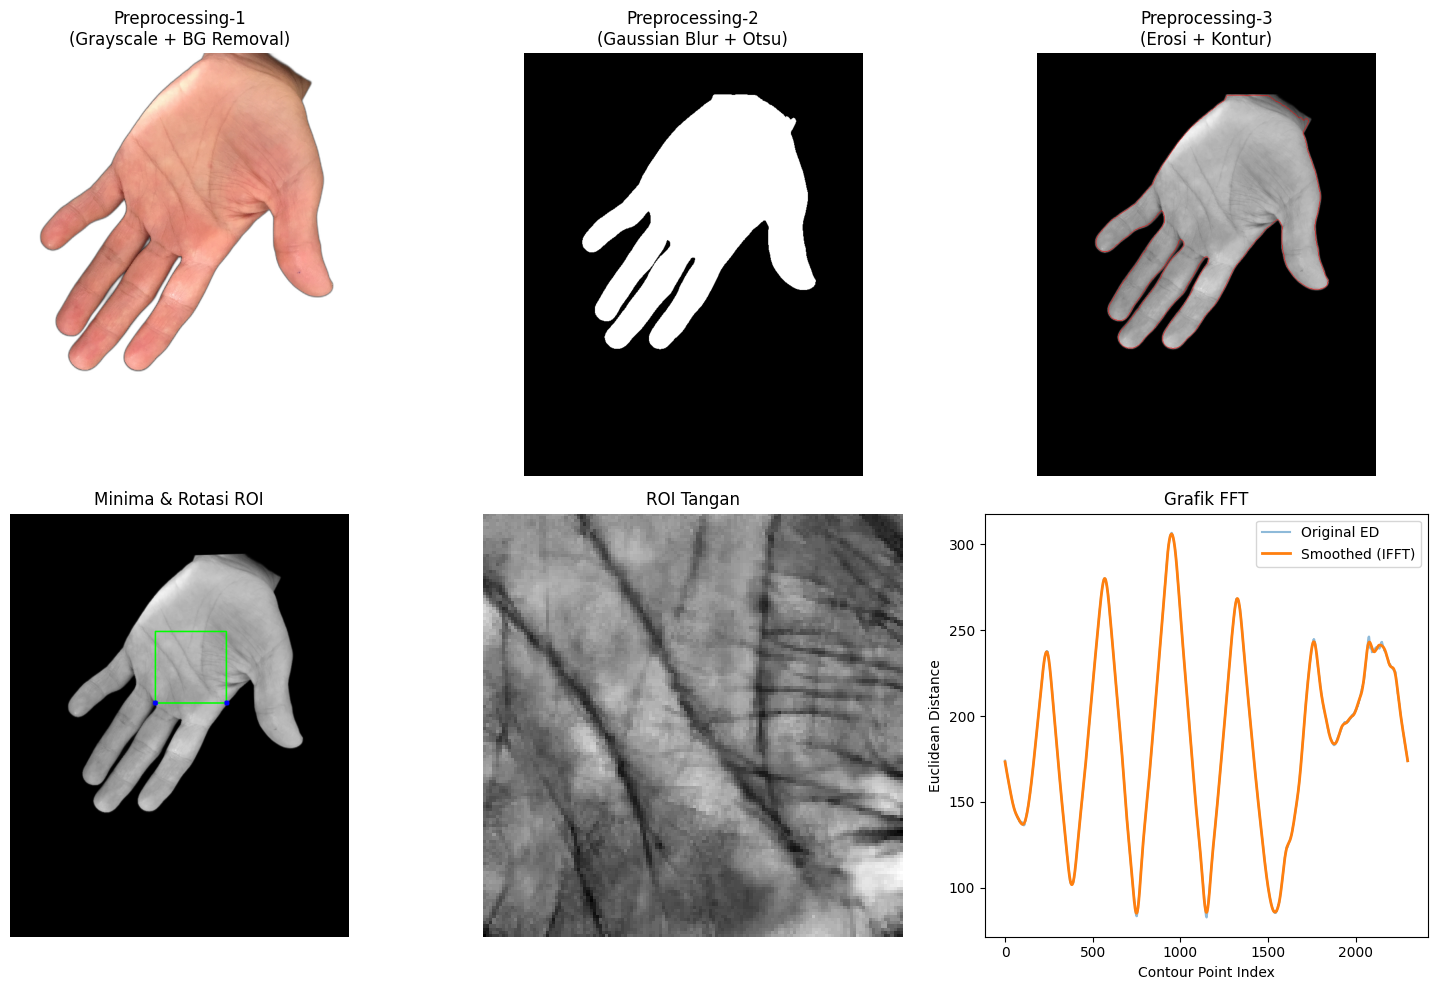

In [7]:
DATASET_DIR = "Dataset"

all_images = []
for person_dir in sorted(os.listdir(DATASET_DIR)):
    person_path = os.path.join(DATASET_DIR, person_dir)
    if os.path.isdir(person_path):
        for img_file in os.listdir(person_path):
            if img_file.lower().endswith(('.png', '.tiff', '.tif', '.jpg', '.jpeg', '.bmp')):
                all_images.append(os.path.join(person_path, img_file))

print(f"Total gambar ditemukan: {len(all_images)}")
print(f"Sample: {all_images[5]}")

sample_path = all_images[5]
result = extract_roi(sample_path)

if result is not None:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Preprocessing-1: Grayscale + Background Removal
    axes[0, 0].imshow(np.array(result['preprocessed_1']), cmap='gray')
    axes[0, 0].set_title("Preprocessing-1\n(Grayscale + BG Removal)")
    axes[0, 0].axis('off')

    # Preprocessing-2: Thresholding Otsu
    axes[0, 1].imshow(result['threshold'], cmap='gray')
    axes[0, 1].set_title("Preprocessing-2\n(Gaussian Blur + Otsu)")
    axes[0, 1].axis('off')

    # Preprocessing-3: Kontur
    axes[0, 2].imshow(cv2.cvtColor(result['contour_img'], cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title("Preprocessing-3\n(Erosi + Kontur)")
    axes[0, 2].axis('off')

    # Rotated image with ROI box
    ux, uy, lx, ly = result['bbox']
    img_display = cv2.cvtColor(result['rotated'], cv2.COLOR_GRAY2BGR)
    cv2.rectangle(img_display, (ux, uy), (lx, ly), (0, 255, 0), 2)
    cv2.circle(img_display, tuple(result['v1']), 5, (255, 0, 0), -1)
    cv2.circle(img_display, tuple(result['v2']), 5, (255, 0, 0), -1)
    axes[1, 0].imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title("Minima & Rotasi ROI")
    axes[1, 0].axis('off')

    # ROI
    axes[1, 1].imshow(result['roi'], cmap='gray')
    axes[1, 1].set_title("ROI Tangan")
    axes[1, 1].axis('off')

    # FFT Graph
    axes[1, 2].plot(result['dist_c'], alpha=0.5, label='Original ED')
    axes[1, 2].plot(result['dist_c_1'], label='Smoothed (IFFT)', linewidth=2)
    axes[1, 2].set_title("Grafik FFT")
    axes[1, 2].set_xlabel("Contour Point Index")
    axes[1, 2].set_ylabel("Euclidean Distance")
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

### Proses Seluruh Dataset dan Pembagian Train/Val/Test

Memproses seluruh gambar dalam dataset untuk mendapatkan ROI, kemudian membagi menjadi folder `dataset/train`, `dataset/val`, dan `dataset/test`.

In [ ]:
DATASET_DIR = "Dataset/dataset_mentah/"
OUTPUT_DIR = "Dataset/dataset_preprocessing/"
LBP_DIR = "Dataset/dataset_lbp"

In [9]:
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(42)

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

person_dirs = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

print(f"Jumlah kelas/person: {len(person_dirs)}")

success_count = 0
fail_count = 0

for person_name in tqdm(person_dirs, desc="Processing persons"):
    person_path = os.path.join(DATASET_DIR, person_name)
    image_files = [
        f for f in os.listdir(person_path)
        if f.lower().endswith(('.png', '.tiff', '.tif', '.jpg', '.jpeg', '.bmp'))
    ]
    image_files.sort()
    random.shuffle(image_files)

    n = len(image_files)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    splits = {
        'train': image_files[:n_train],
        'val': image_files[n_train:n_train + n_val],
        'test': image_files[n_train + n_val:]
    }

    for split_name, files in splits.items():
        split_person_dir = os.path.join(OUTPUT_DIR, split_name, person_name)
        os.makedirs(split_person_dir, exist_ok=True)

        for img_file in files:
            img_path = os.path.join(person_path, img_file)
            result = extract_roi(img_path)

            if result is not None and result['roi'].size > 0:
                roi = result['roi']
                h, w = roi.shape[:2]

                # Filter ROI terlalu kecil (gagal ekstraksi) — minimal 50x50 piksel
                if h < 50 or w < 50:
                    fail_count += 1
                    continue

                out_path = os.path.join(
                    split_person_dir,
                    os.path.splitext(img_file)[0] + ".png"
                )
                cv2.imwrite(out_path, roi)
                success_count += 1
            else:
                fail_count += 1

print(f"\nSelesai! Berhasil: {success_count}, Gagal: {fail_count}")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(OUTPUT_DIR, split)
    total = sum(len(files) for _, _, files in os.walk(split_path))
    print(f"  {split}: {total} gambar")

Jumlah kelas/person: 28


Processing persons: 100%|██████████| 28/28 [31:09<00:00, 66.76s/it]


Selesai! Berhasil: 1110, Gagal: 10
  train: 776 gambar
  val: 168 gambar
  test: 166 gambar


In [10]:
from skimage.feature import local_binary_pattern
from pathlib import Path

def create_lbp_dataset(input_base_dir, output_base_dir):
    """
    Reads all images in the input directory, applies LBP, 
    converts them to 3-channel, and saves them to the output directory.
    """
    input_path = Path(input_base_dir)
    output_path = Path(output_base_dir)
    
    # LBP Parameters
    radius = 3
    n_points = 8 * radius

    for split in ['train', 'val', 'test']:
        split_in = input_path / split
        split_out = output_path / split
        
        if not split_in.exists():
            continue
            
        # Iterate through every class folder
        for class_dir in split_in.iterdir():
            if not class_dir.is_dir():
                continue
                
            out_class_dir = split_out / class_dir.name
            out_class_dir.mkdir(parents=True, exist_ok=True)
            
            for img_file in class_dir.glob('*.*'): # Matches .jpg, .png, etc.
                # 1. Load image
                img = cv2.imread(str(img_file))
                if img is None: continue
                
                # 2. Convert to grayscale
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                
                # 3. Apply LBP
                lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
                lbp = np.uint8(255 * lbp / lbp.max())
                
                # 4. Convert 1-channel LBP to 3-channel (Duplicate grayscale across RGB)
                # This satisfies EfficientNet's 3-channel requirement
                lbp_3channel = cv2.cvtColor(lbp, cv2.COLOR_GRAY2BGR)
                
                # 5. Save the new LBP image
                cv2.imwrite(str(out_class_dir / img_file.name), lbp_3channel)
                
    print(f"LBP dataset successfully created at: {output_base_dir}")

# Run this ONCE to create your new dataset folders
create_lbp_dataset(f"{OUTPUT_DIR}", f"{LBP_DIR}")

LBP dataset successfully created at: dataset_lbp


## Ekstraksi Fitur

Ekstraksi fitur mengandalkan kemampuan CNN dalam mengekstraksi representasi visual dari citra. Proses dimulai dari tahap preprocessing berupa normalisasi ukuran citra, konversi warna, dan augmentasi data untuk meningkatkan keragaman. Selanjutnya, citra dimasukkan ke dalam arsitektur CNN.

### Ekstraksi Fitur dengan CNN

Model CNN berbasis **EfficientNetB0** dengan pendekatan transfer learning (bobot awal dari ImageNet). Lapisan atas dihilangkan dan disesuaikan dengan jumlah kelas dataset. Ditambahkan Global Average Pooling, Dropout (0.3), dan Dense layer softmax sebagai output.

2026-03-12 10:52:01.382686: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 776 files belonging to 28 classes.


I0000 00:00:1773287529.738501    3659 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2240 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Found 168 files belonging to 28 classes.
Found 166 files belonging to 28 classes.
Number of classes: 28


Model: "functional_1"

...

Epoch 1/200


E0000 00:00:1773287560.057580    3659 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-03-12 10:52:42.306702: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33558016 bytes after encountering the first element of size 33558016 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-03-12 10:52:44.154297: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 661ms/step - accuracy: 0.4652 - loss: 2.1371 - val_accuracy: 0.3988 - val_loss: 2.0504 - learning_rate: 0.0010
Epoch 2/200


2026-03-12 10:53:01.565406: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33558528 bytes after encountering the first element of size 33558528 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 431ms/step - accuracy: 0.8634 - loss: 0.5894 - val_accuracy: 0.5893 - val_loss: 1.2932 - learning_rate: 0.0010
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 441ms/step - accuracy: 0.9304 - loss: 0.2757 - val_accuracy: 0.8274 - val_loss: 0.5648 - learning_rate: 0.0010
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 406ms/step - accuracy: 0.9665 - loss: 0.1420 - val_accuracy: 0.8929 - val_loss: 0.4273 - learning_rate: 0.0010
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 432ms/step - accuracy: 0.9729 - loss: 0.0964 - val_accuracy: 0.8929 - val_loss: 0.4014 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 428ms/step - accuracy: 0.9948 - loss: 0.0525 - val_accuracy: 0.9107 - val_loss: 0.4214 - learning_rate: 0.0010
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 409ms/step - accuracy: 0.9807 - loss: 0.0750 - val_accuracy: 0.8869 - val_loss: 0.4839 - learning_rate: 0.0010
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 422ms/step - accuracy: 0.9807 - loss: 0.0797 

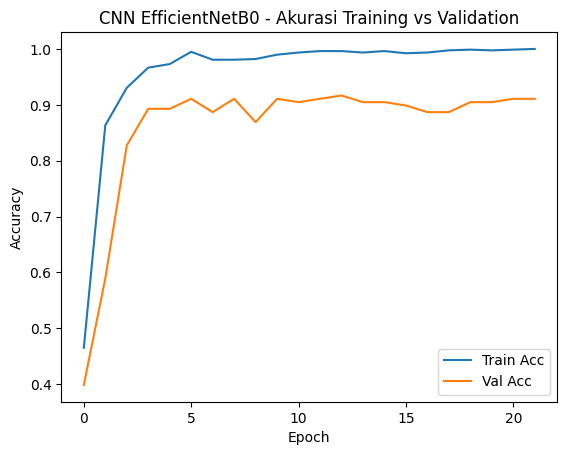

Model CNN disimpan sebagai palm_recognition1.keras


In [ ]:
import tensorflow as tf
# import keras_cv
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
MODEL_NAME = "palm_recognition1"

train_ds = image_dataset_from_directory(
    f"{OUTPUT_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"  # multi-class
)

val_ds = image_dataset_from_directory(
    f"{OUTPUT_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = image_dataset_from_directory(
    f"{OUTPUT_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

NUM_CLASSES = len(train_ds.class_names)
print(f"Number of classes: {NUM_CLASSES}")

# Prefetch untuk percepatan
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# -----------------------------
# 2. Data Augmentation
# -----------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05, 
                             fill_mode='constant', fill_value=0.0),
    layers.RandomRotation(factor=0.014, fill_mode='constant', fill_value=0.0),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2),
    layers.GaussianNoise(stddev=0.05)
])

# -----------------------------
# 3. Model CNN (EfficientNetB0)
# -----------------------------
base_model = EfficientNetB0(weights="imagenet", include_top=False,
                            input_shape=IMG_SIZE + (3,))
base_model.trainable = True

# Opsional: Jika dataset sedikit, freeze setengah layer awal, buka setengah layer akhir
for layer in base_model.layers[:100]:
    layer.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
# x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)  # Regularisasi
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

# -----------------------------
# 4. Compile Model
# -----------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# 5. Train Model
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                         restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,             # Cut the learning rate in half
            patience=4,             # If no improvement for 4 epochs
            min_lr=1e-6,            # Lower bound for the learning rate
            verbose=1
        )
    ]
)

# -----------------------------
# 6. Evaluate
# -----------------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

# -----------------------------
# 7. Plot Akurasi & Loss
# -----------------------------
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN EfficientNetB0 - Akurasi Training vs Validation")
plt.show()

model.save(f"{MODEL_NAME}.keras")
print(f"Model CNN disimpan sebagai {MODEL_NAME}.keras")

In [4]:
# model = tf.keras.models.load_model('cnn3.keras')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(f"{MODEL_NAME}.tflite", 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpdlk41hyv/assets


INFO:tensorflow:Assets written to: /tmp/tmpdlk41hyv/assets


Saved artifact at '/tmp/tmpdlk41hyv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 28), dtype=tf.float32, name=None)
Captures:
  133209450817552: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133209450818128: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133210388818512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388819856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388810256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388820624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388818320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388816208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388821776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388821968: TensorSpec(shape=(), dtype=tf.resource, name

W0000 00:00:1773287827.398095    3659 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773287827.414901    3659 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-12 10:57:07.447405: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpdlk41hyv
2026-03-12 10:57:07.466338: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-12 10:57:07.466376: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpdlk41hyv
I0000 00:00:1773287827.852598    3659 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-03-12 10:57:07.901799: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-12 10:57:09.445928: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpdlk41hyv
2026-03-12 10:57:09.849891: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

### Ekstraksi Fitur dengan CNN dan LBP

LBP (Local Binary Pattern) digunakan sebagai metode ekstraksi fitur tekstur yang bekerja dengan membandingkan intensitas piksel pusat terhadap tetangganya (radius=3, n_points=24), menghasilkan pola biner yang merepresentasikan karakteristik lokal citra telapak tangan.

Kombinasi teknik ekstraksi fitur berbasis tekstur (LBP) dan deep learning (EfficientNetB0) lebih efektif dalam mengenali pola biometrik telapak tangan dibandingkan penggunaan CNN saja.

Found 776 files belonging to 28 classes.
Found 168 files belonging to 28 classes.
Found 166 files belonging to 28 classes.
Number of classes: 28
Epoch 1/200


E0000 00:00:1773287860.103923    3659 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 511ms/step - accuracy: 0.2655 - loss: 2.7312 - val_accuracy: 0.2917 - val_loss: 2.5548 - learning_rate: 0.0010
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 440ms/step - accuracy: 0.6778 - loss: 1.2827 - val_accuracy: 0.4286 - val_loss: 2.0570 - learning_rate: 0.0010
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 425ms/step - accuracy: 0.8106 - loss: 0.6646 - val_accuracy: 0.6488 - val_loss: 1.5167 - learning_rate: 0.0010
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 434ms/step - accuracy: 0.9059 - loss: 0.3903 - val_accuracy: 0.7083 - val_loss: 1.2305 - learning_rate: 0.0010
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 441ms/step - accuracy: 0.9356 - loss: 0.2580 - val_accuracy: 0.7798 - val_loss: 1.0081 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 416ms/step - accuracy: 0.9549 - loss: 0.1805 - val_accuracy: 0.7917 - val_loss: 0.8650 - learning_rate: 0.0010
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 444ms/step - accuracy: 0.9601 - loss: 0.1481 

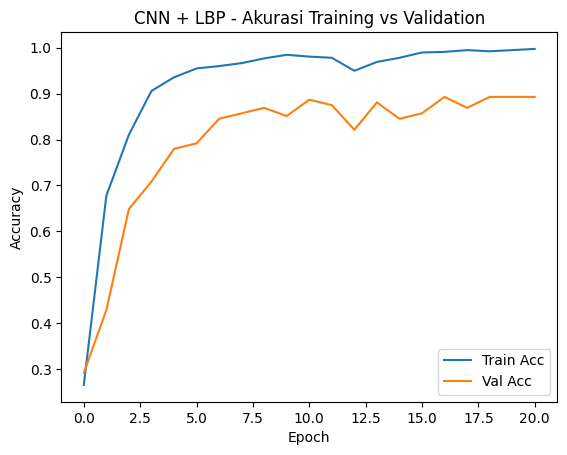

Model CNN disimpan sebagai palm_recognition1.keras


In [5]:
train_ds = image_dataset_from_directory(
    f"{LBP_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"  # multi-class
)

val_ds = image_dataset_from_directory(
    f"{LBP_DIR}/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = image_dataset_from_directory(
    f"{LBP_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

NUM_CLASSES = len(train_ds.class_names)
print(f"Number of classes: {NUM_CLASSES}")

base_model = EfficientNetB0(weights="imagenet", include_top=False,
                            input_shape=IMG_SIZE + (3,))
base_model.trainable = True

# Opsional: Jika dataset sedikit, freeze setengah layer awal, buka setengah layer akhir
for layer in base_model.layers[:100]:
    layer.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
# x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)  # Regularisasi
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_lbp = models.Model(inputs, outputs)

# -----------------------------
# 4. Compile & Train
# -----------------------------
model_lbp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_lbp = model_lbp.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                         restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,             # Cut the learning rate in half
            patience=4,             # If no improvement for 4 epochs
            min_lr=1e-6,            # Lower bound for the learning rate
            verbose=1
        )
    ]
)

# -----------------------------
# 5. Evaluate
# -----------------------------
test_loss, test_acc = model_lbp.evaluate(test_ds)
print(f"Test Accuracy with LBP: {test_acc:.4f}")

# -----------------------------
# 6. Plot Akurasi & Loss
# -----------------------------
plt.plot(history_lbp.history["accuracy"], label="Train Acc")
plt.plot(history_lbp.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN + LBP - Akurasi Training vs Validation")
plt.show()

model_lbp.save(f"{MODEL_NAME}_lbp.keras")
print(f"Model CNN disimpan sebagai {MODEL_NAME}.keras")

In [6]:
# model = tf.keras.models.load_model('cnn3.keras')
converter_lbp = tf.lite.TFLiteConverter.from_keras_model(model_lbp)
converter_lbp.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_lbp = converter_lbp.convert()

with open(f"{MODEL_NAME}_lbp.tflite", 'wb') as f:
    f.write(tflite_model_lbp)

INFO:tensorflow:Assets written to: /tmp/tmpeayjf97t/assets


INFO:tensorflow:Assets written to: /tmp/tmpeayjf97t/assets


Saved artifact at '/tmp/tmpeayjf97t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_488')
Output Type:
  TensorSpec(shape=(None, 28), dtype=tf.float32, name=None)
Captures:
  133204719305360: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133204719304976: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133210388813328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388811408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388813520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388811216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388810064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388811792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210393224080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133210388812368: TensorSpec(shape=(), dtype=tf.resource, name

W0000 00:00:1773288105.385081    3659 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773288105.385146    3659 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-12 11:01:45.388246: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpeayjf97t
2026-03-12 11:01:45.404606: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-12 11:01:45.404643: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpeayjf97t
2026-03-12 11:01:45.622008: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-12 11:01:46.588905: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpeayjf97t
2026-03-12 11:01:46.886179: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 1497939 microseconds.


## Confusion Matrix

Pengujian model menggunakan confusion matrix sebagai alat evaluasi utama untuk mengukur performa klasifikasi. Metrik yang dianalisis adalah akurasi, precision, recall, dan F1-score.

EVALUASI MODEL CNN (EfficientNetB0)
Found 166 files belonging to 28 classes.


2026-03-12 11:01:49.136596: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19267584 exceeds 10% of free system memory.
2026-03-12 11:01:51.564881: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19267584 exceeds 10% of free system memory.
2026-03-12 11:01:51.819314: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19267584 exceeds 10% of free system memory.
2026-03-12 11:01:52.066947: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19267584 exceeds 10% of free system memory.
2026-03-12 11:01:52.315260: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19267584 exceeds 10% of free system memory.
2026-03-12 11:01:54.541937: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Classification Report (CNN):
                           precision    recall  f1-score   support

           Abi Al Qhafari       0.86      1.00      0.92         6
           Aldin Pramudya       1.00      1.00      1.00         6
        Cahaya Indrasmara       1.00      0.83      0.91         6
    Dewa Anggoro Mulianto       1.00      1.00      1.00         6
             Dhana Reyhan       1.00      1.00      1.00         6
        Fajar Cita Wibowo       0.80      0.67      0.73         6
            Fauzan Habibi       1.00      1.00      1.00         6
        Ikrar Budi Dharma       0.83      0.83      0.83         6
         Ken Arya Rizkyka       1.00      1.00      1.00         5
   MUHAMMAD HAIDAR SHAHAB       0.83      1.00      0.91         5
           Marthalita Dwi       1.00      1.00      1.00         6
 Muhamad Enrinal Zulhimar       1.00      1.00      1.00         6
    Muhammad Ariq Pratama       1.00      1.00      1.00         6
          Muhammad Gading      

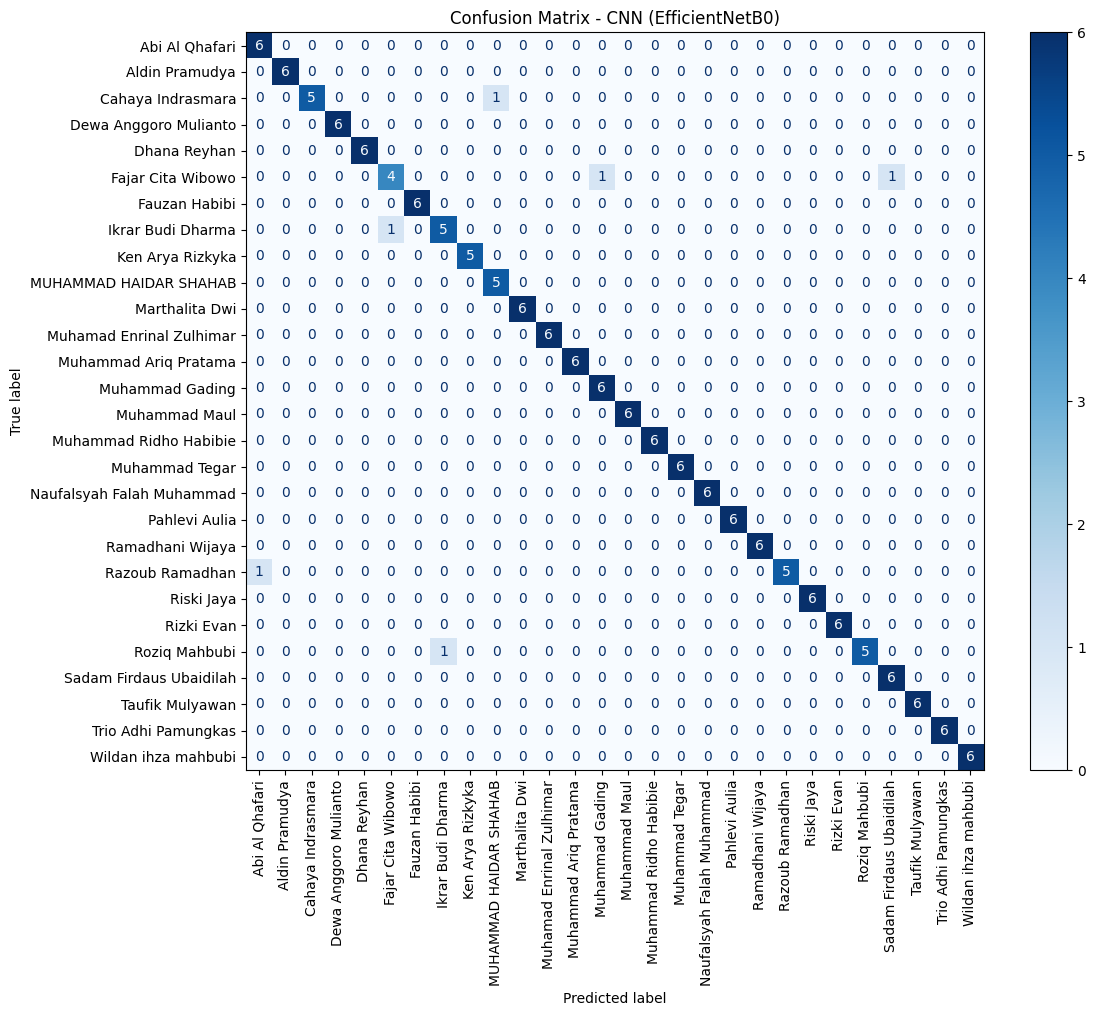

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# --- Evaluasi Model CNN ---
print("=" * 60)
print("EVALUASI MODEL CNN (EfficientNetB0)")
print("=" * 60)

test_ds_eval = image_dataset_from_directory(
    f"{OUTPUT_DIR}/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)

class_names = test_ds_eval.class_names
NUM_CLASSES_EVAL = len(class_names)

y_true = []
y_pred_cnn = []

for images, batch_labels in test_ds_eval:
    preds = model.predict(images, verbose=0)
    y_true.extend(batch_labels.numpy().astype(int))
    y_pred_cnn.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred_cnn = np.array(y_pred_cnn)

labels = list(range(len(class_names)))

print("\nClassification Report (CNN):")
print(classification_report(y_true, y_pred_cnn, target_names=class_names, labels=labels, zero_division=0))

cm_cnn = confusion_matrix(y_true, y_pred_cnn, labels=labels)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix - CNN (EfficientNetB0)")
plt.tight_layout()
plt.show()

EVALUASI MODEL CNN + LBP
Found 166 files belonging to 28 classes.


2026-03-12 11:02:00.559100: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Classification Report (CNN + LBP):
                           precision    recall  f1-score   support

           Abi Al Qhafari       1.00      1.00      1.00         6
           Aldin Pramudya       1.00      1.00      1.00         6
        Cahaya Indrasmara       1.00      0.67      0.80         6
    Dewa Anggoro Mulianto       1.00      1.00      1.00         6
             Dhana Reyhan       1.00      1.00      1.00         6
        Fajar Cita Wibowo       0.75      0.50      0.60         6
            Fauzan Habibi       0.83      0.83      0.83         6
        Ikrar Budi Dharma       1.00      0.67      0.80         6
         Ken Arya Rizkyka       0.80      0.80      0.80         5
   MUHAMMAD HAIDAR SHAHAB       1.00      1.00      1.00         5
           Marthalita Dwi       0.75      1.00      0.86         6
 Muhamad Enrinal Zulhimar       0.86      1.00      0.92         6
    Muhammad Ariq Pratama       0.86      1.00      0.92         6
          Muhammad Gading

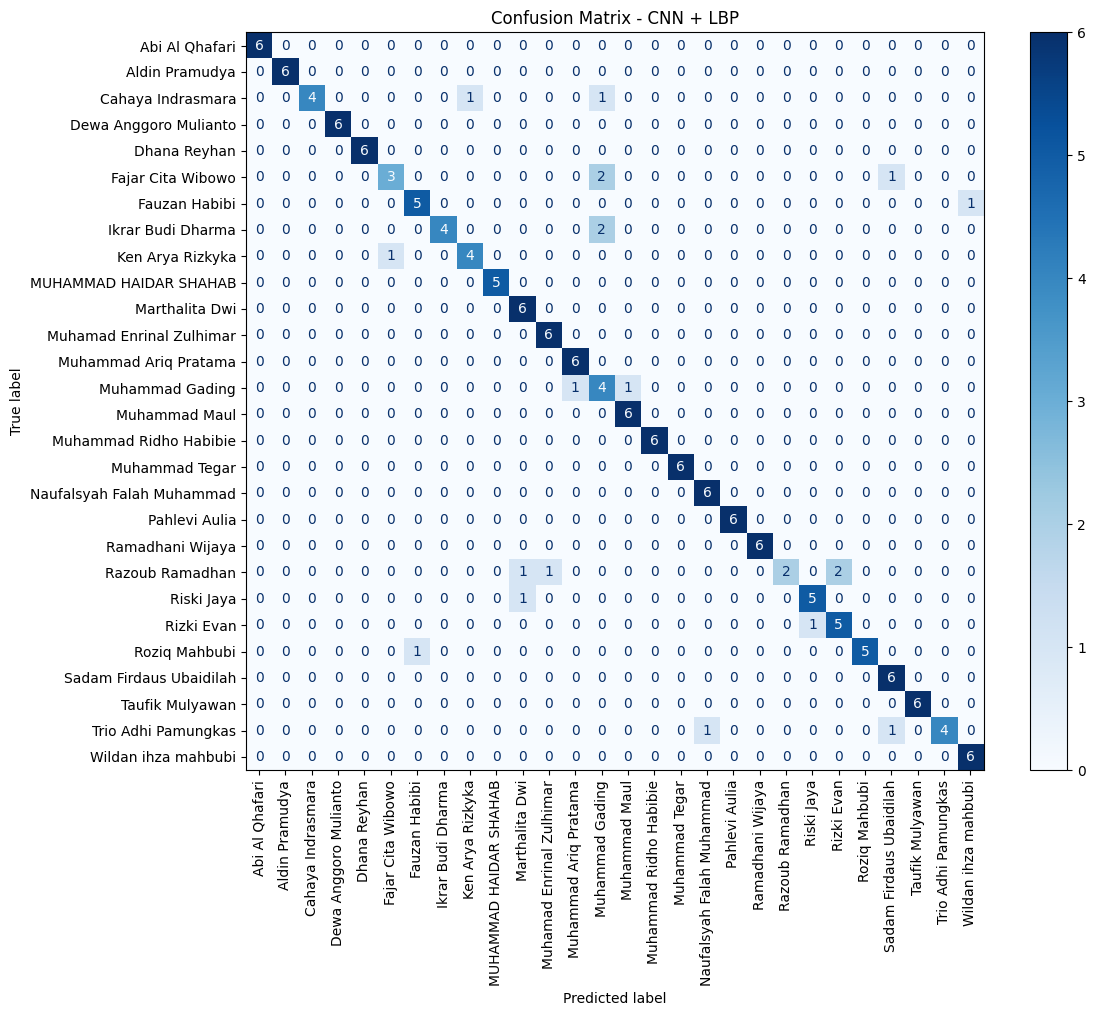

In [8]:
# --- Evaluasi Model CNN + LBP ---
print("=" * 60)
print("EVALUASI MODEL CNN + LBP")
print("=" * 60)

test_ds_eval = image_dataset_from_directory(
    f"{LBP_DIR}/test", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False
)

class_names = test_ds_eval.class_names
NUM_CLASSES_EVAL = len(class_names)

labels = list(range(len(class_names)))

y_pred_lbp = []

for images, batch_labels in test_ds_eval:
    preds = model_lbp.predict(images, verbose=0)
    y_pred_lbp.extend(np.argmax(preds, axis=1))

y_pred_lbp = np.array(y_pred_lbp)

print("\nClassification Report (CNN + LBP):")
print(classification_report(y_true, y_pred_lbp, target_names=class_names, labels=labels, zero_division=0))

cm_lbp = confusion_matrix(y_true, y_pred_lbp, labels=labels)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lbp, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix - CNN + LBP")
plt.tight_layout()
plt.show()

PERBANDINGAN HASIL
           Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
CNN        0.963855           0.965646        0.964286          0.963079
CNN + LBP  0.879518           0.898611        0.879762          0.875285


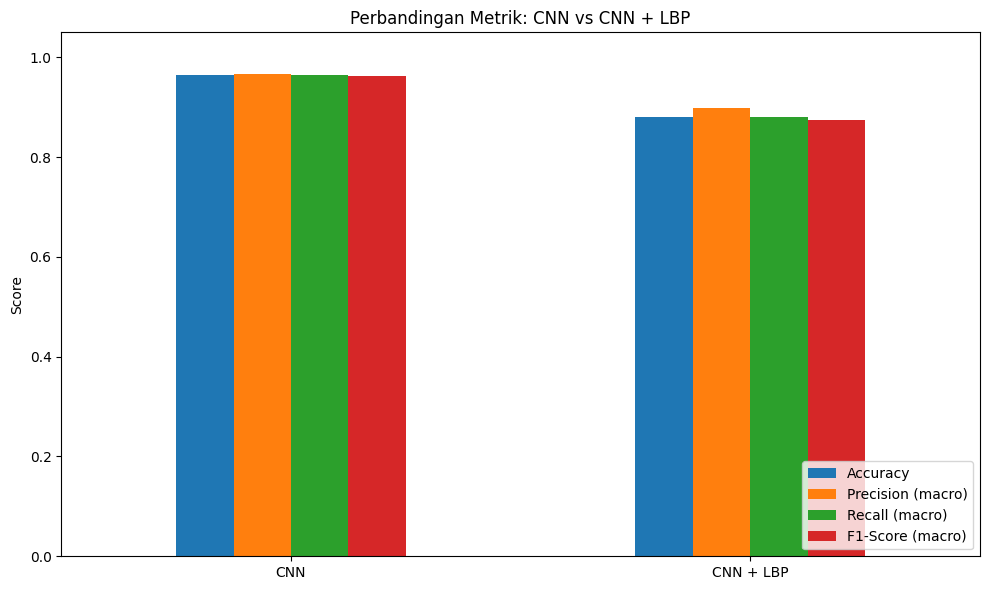

In [9]:
# --- Perbandingan Hasil ---
print("=" * 60)
print("PERBANDINGAN HASIL")
print("=" * 60)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {}
for name, y_pred in [("CNN", y_pred_cnn), ("CNN + LBP", y_pred_lbp)]:
    metrics[name] = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "F1-Score (macro)": f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

import pandas as pd
df_metrics = pd.DataFrame(metrics).T
print(df_metrics.to_string())

df_metrics.plot(kind='bar', figsize=(10, 6))
plt.title("Perbandingan Metrik: CNN vs CNN + LBP")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()